In [ ]:
import pandas as pd
df = pd.read_csv("data/processed/jm1_clean.csv")
df.head()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects,defects_str
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,1.2,1.2,1.2,1.2,1.4,0,0
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1.0,1.0,1.0,1.0,1.0,1,1
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,10,8,1,17.0,36.0,112.0,86.0,13.0,1,1
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,29,28,2,17.0,135.0,329.0,271.0,5.0,1,1
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,1,6,0,11.0,16.0,76.0,50.0,7.0,1,1


In [ ]:
df = df.drop(columns=['defects_str'])

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('defects', axis=1)
y = df['defects']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)


(defects
 0    0.8065
 1    0.1935
 Name: proportion, dtype: float64,
 defects
 0    0.806615
 1    0.193385
 Name: proportion, dtype: float64)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix, precision_recall_fscore_support

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced' #For imbalance
)

rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred  = (rf_proba >= 0.5).astype(int) 

rf_roc  = roc_auc_score(y_test, rf_proba)
rf_pra  = average_precision_score(y_test, rf_proba)  # PR-AUC
print("RF ROC-AUC:", round(rf_roc, 4))
print("RF PR-AUC :", round(rf_pra, 4))
print("\n[RF] Classification report (th=0.5):\n", classification_report(y_test, rf_pred, digits=4))
print("[RF] Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))


RF ROC-AUC: 0.7162
RF PR-AUC : 0.4037

[RF] Classification report (th=0.5):
               precision    recall  f1-score   support

           0     0.8348    0.9413    0.8849      1756
           1     0.4772    0.2233    0.3042       421

    accuracy                         0.8025      2177
   macro avg     0.6560    0.5823    0.5946      2177
weighted avg     0.7657    0.8025    0.7726      2177

[RF] Confusion Matrix:
 [[1653  103]
 [ 327   94]]


In [ ]:
pip install xgboost


In [ ]:

from xgboost import XGBClassifier

import numpy as np
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
spw = neg / max(pos, 1)

xgb = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    objective='binary:logistic',
    eval_metric='logloss',      
    scale_pos_weight=spw        # Gives more weight to the minority class in the dataset
)

xgb.fit(X_train, y_train)


xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_pred  = (xgb_proba >= 0.5).astype(int)


from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
xgb_roc = roc_auc_score(y_test, xgb_proba)
xgb_pra = average_precision_score(y_test, xgb_proba)
print("XGB ROC-AUC:", round(xgb_roc, 4))
print("XGB PR-AUC :", round(xgb_pra, 4))
print("\n[XGB] Classification report (th=0.5):\n", classification_report(y_test, xgb_pred, digits=4))
print("[XGB] Confusion Matrix:\n", confusion_matrix(y_test, xgb_pred))


XGB ROC-AUC: 0.71
XGB PR-AUC : 0.4009

[XGB] Classification report (th=0.5):
               precision    recall  f1-score   support

           0     0.8608    0.8138    0.8367      1756
           1     0.3675    0.4513    0.4051       421

    accuracy                         0.7437      2177
   macro avg     0.6142    0.6325    0.6209      2177
weighted avg     0.7654    0.7437    0.7532      2177

[XGB] Confusion Matrix:
 [[1429  327]
 [ 231  190]]


In [15]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

def summarize(y_true, proba, name, thr=0.5):
    pred = (proba >= thr).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, pred, average='binary', zero_division=0)
    return {
        "Model": name,
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
        "Precision(1)": prec,
        "Recall(1)": rec,
        "F1(1)": f1
    }

summary = pd.DataFrame([
    summarize(y_test, rf_proba,  "RandomForest"),
    summarize(y_test, xgb_proba, "XGBoost")
]).round(4)

summary


,Model,ROC-AUC,PR-AUC,Precision(1),Recall(1),F1(1)
0,RandomForest,0.7162,0.4037,0.4772,0.2233,0.3042
1,XGBoost,0.7100,0.4009,0.3675,0.4513,0.4051


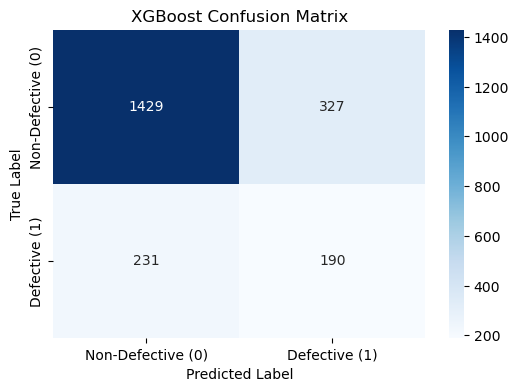

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, xgb_pred)
labels = ['Non-Defective (0)', 'Defective (1)']

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, f1_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score
import numpy as np

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

from xgboost import XGBClassifier

pos = (y_tr == 1).sum()
neg = (y_tr == 0).sum()
spw = neg / max(pos, 1)

xgb_val = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=spw
)
xgb_val.fit(X_tr, y_tr)

p_val = xgb_val.predict_proba(X_val)[:, 1]    # Validation

prec, rec, thr = precision_recall_curve(y_val, p_val)
f1s = 2 * (prec * rec) / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1s)
best_thr_f1 = thr[best_idx]
best_f1 = f1s[best_idx]
best_prec = prec[best_idx]
best_rec  = rec[best_idx]

print(f"Validation'da F1-max eşik = {best_thr_f1:.3f} | F1={best_f1:.3f} | P={best_prec:.3f} | R={best_rec:.3f}")

target_recall = 0.55
idx_rec = np.where(rec >= target_recall)[0]
best_thr_rec = thr[idx_rec[0]] if len(idx_rec) else 0.5
if len(idx_rec):
    print(f"Validation'da Recall>={target_recall:.2f} için eşik ≈ {best_thr_rec:.3f}")


Validation'da F1-max eşik = 0.347 | F1=0.448 | P=0.348 | R=0.626
Validation'da Recall>=0.55 için eşik ≈ 0.001


In [ ]:

pos_all = (y_train == 1).sum()
neg_all = (y_train == 0).sum()
spw_all = neg_all / max(pos_all, 1)

xgb_final = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=spw_all
)
xgb_final.fit(X_train, y_train)

p_test = xgb_final.predict_proba(X_test)[:, 1]

pred_f1 = (p_test >= best_thr_f1).astype(int)

print("=== XGB | F1-max eşik ile TEST sonuçları ===")
print("ROC-AUC:", round(roc_auc_score(y_test, p_test), 4))
print("PR-AUC :", round(average_precision_score(y_test, p_test), 4))
print(classification_report(y_test, pred_f1, digits=4))
print(confusion_matrix(y_test, pred_f1))


=== XGB | F1-max eşik ile TEST sonuçları ===
ROC-AUC: 0.71
PR-AUC : 0.4009
              precision    recall  f1-score   support

           0     0.8805    0.6754    0.7644      1756
           1     0.3133    0.6176    0.4157       421

    accuracy                         0.6642      2177
   macro avg     0.5969    0.6465    0.5900      2177
weighted avg     0.7708    0.6642    0.6970      2177

[[1186  570]
 [ 161  260]]


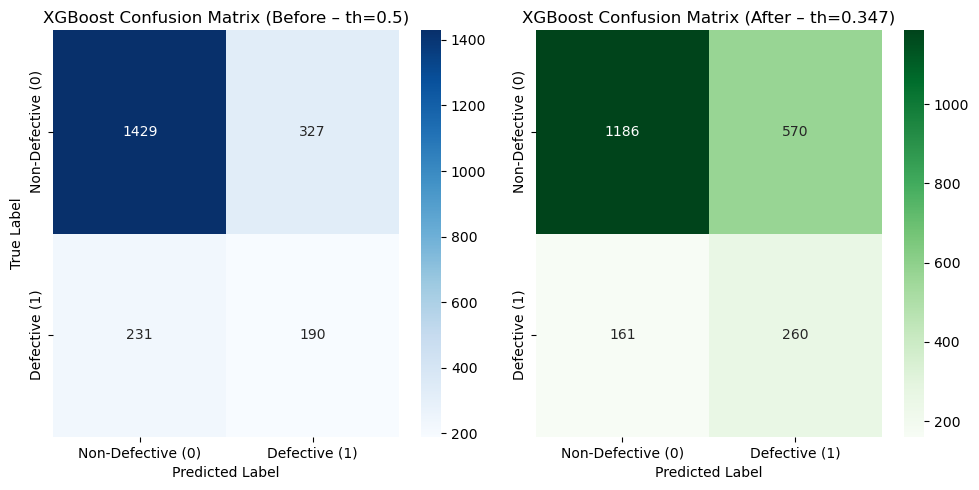

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_before = np.array([[1429, 327],
                      [231, 190]])  

cm_after = np.array([[1186, 570],
                     [161, 260]]) 

labels = ['Non-Defective (0)', 'Defective (1)']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('XGBoost Confusion Matrix (Before – th=0.5)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_after, annot=True, fmt='d', cmap='Greens', 
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('XGBoost Confusion Matrix (After – th=0.347)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': [200, 400, 600, 800],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5],
    'scale_pos_weight': [2, 3, 4, 5]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    scoring='f1',     # Target metric
    n_iter=30,        # 30 combination
    cv=3,             # 3 fold cross validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("En iyi parametre seti:", random_search.best_params_)
print("En iyi CV F1 skoru:", round(random_search.best_score_, 4))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
En iyi parametre seti: {'subsample': 1.0, 'scale_pos_weight': 4, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 1.0}
En iyi CV F1 skoru: 0.4516


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
import numpy as np
from xgboost import XGBClassifier

best_params = {
    'subsample': 1.0,
    'scale_pos_weight': 4,
    'n_estimators': 400,
    'min_child_weight': 1,
    'max_depth': 8,
    'learning_rate': 0.01,
    'gamma': 0.3,
    'colsample_bytree': 1.0,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1
}

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

xgb_tuned_val = XGBClassifier(**best_params) # Tuned model for validation 
xgb_tuned_val.fit(X_tr, y_tr)

p_val = xgb_tuned_val.predict_proba(X_val)[:, 1]

prec, rec, thr = precision_recall_curve(y_val, p_val)
f1s = 2 * (prec * rec) / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1s)
best_thr_tuned = thr[best_idx]
print(f"Tuned model | F1-max threshold ≈ {best_thr_tuned:.3f} | P={prec[best_idx]:.3f} | R={rec[best_idx]:.3f}")


Tuned model | F1-max threshold ≈ 0.529 | P=0.432 | R=0.531


In [23]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

xgb_tuned = XGBClassifier(**best_params)
xgb_tuned.fit(X_train, y_train)

p_test_tuned = xgb_tuned.predict_proba(X_test)[:, 1]
y_pred_tuned = (p_test_tuned >= best_thr_tuned).astype(int)

print("=== XGB Tuned | TEST ===")
print("ROC-AUC:", round(roc_auc_score(y_test, p_test_tuned), 4))
print("PR-AUC :", round(average_precision_score(y_test, p_test_tuned), 4))
print(classification_report(y_test, y_pred_tuned, digits=4))
print(confusion_matrix(y_test, y_pred_tuned))


=== XGB Tuned | TEST ===
ROC-AUC: 0.7236
PR-AUC : 0.4053
              precision    recall  f1-score   support

           0     0.8732    0.8041    0.8372      1756
           1     0.3857    0.5131    0.4404       421

    accuracy                         0.7478      2177
   macro avg     0.6295    0.6586    0.6388      2177
weighted avg     0.7789    0.7478    0.7605      2177

[[1412  344]
 [ 205  216]]


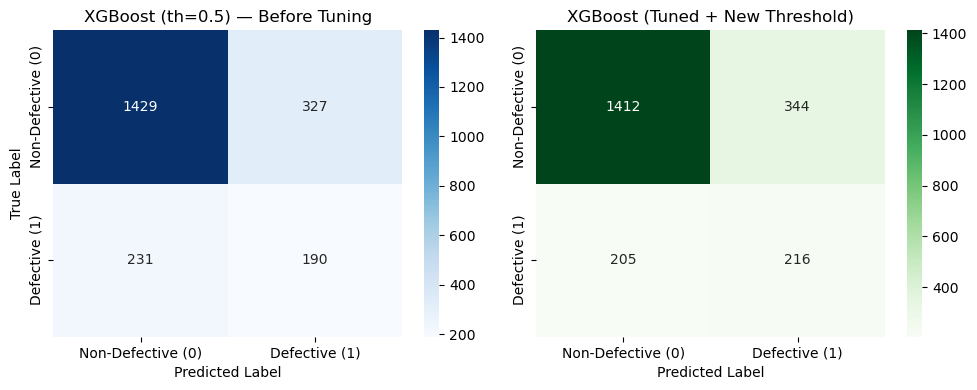

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm_before = np.array([[1429, 327],
                      [231, 190]])


cm_after = np.array([[1412, 344],
                     [205, 216]])

labels = ['Non-Defective (0)', 'Defective (1)']


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("XGBoost (th=0.5) — Before Tuning")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_after, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("XGBoost (Tuned + New Threshold)")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

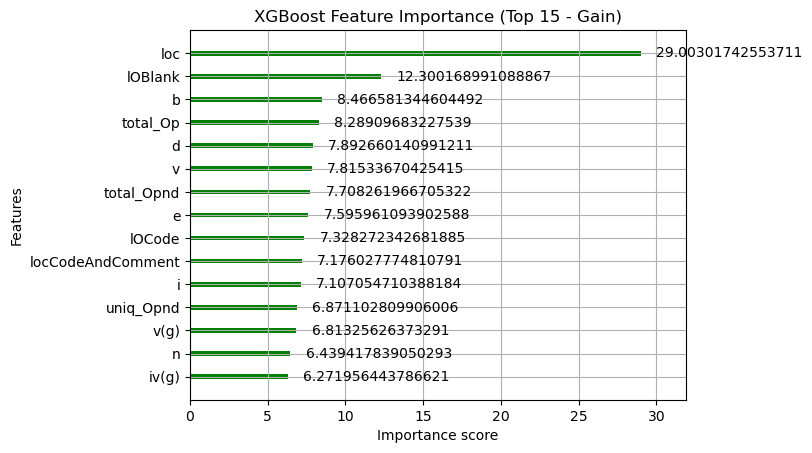

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))   # Feature importance 
plot_importance(xgb_tuned, max_num_features=15, importance_type='gain', color='green')
plt.title('XGBoost Feature Importance (Top 15 - Gain)')
plt.show()


In [ ]:
pip install shap


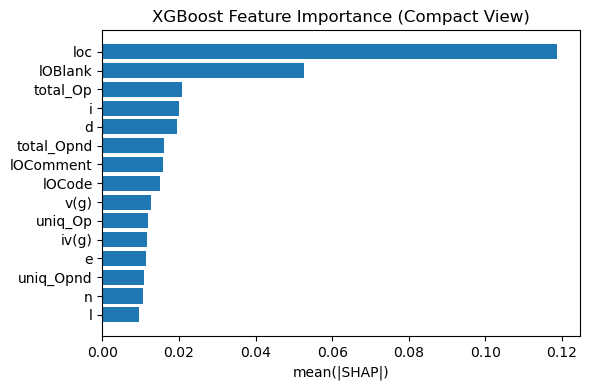

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mean_abs = np.abs(sv.values).mean(axis=0)                   
imp = pd.Series(mean_abs, index=X_test_sample.columns)      
topk = 15
imp_top = imp.sort_values().tail(topk)                      

plt.figure(figsize=(6,4))
plt.barh(imp_top.index, imp_top.values)
plt.xlabel("mean(|SHAP|)")
plt.title("XGBoost Feature Importance (Compact View)")
plt.tight_layout()
plt.show()



C:\Users\Pelin\AppData\Local\Temp\ipykernel_20604\3987813676.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


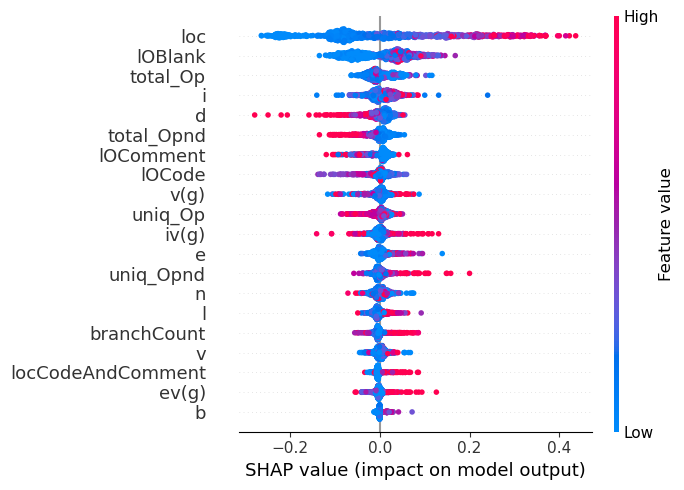

In [39]:
import shap

shap.summary_plot(
    sv.values,
    X_test_sample,
    feature_names=X_test.columns,
    plot_size=(7, 5)
)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_setB = df.copy()

df_setB['loc_per_branch']     = df_setB['loc'] / (df_setB['branchCount'] + 1)
df_setB['complexity_density'] = df_setB['v(g)'] / (df_setB['loc'] + 1)
df_setB['essential_density']  = df_setB['ev(g)'] / (df_setB['loc'] + 1)
df_setB['design_density']     = df_setB['iv(g)'] / (df_setB['loc'] + 1)
df_setB['volume_per_loc']     = df_setB['v'] / (df_setB['loc'] + 1)
df_setB['effort_per_loc']     = df_setB['e'] / (df_setB['loc'] + 1)
df_setB['difficulty_per_loc'] = df_setB['d'] / (df_setB['loc'] + 1)
df_setB['branch_density']     = df_setB['branchCount'] / (df_setB['loc'] + 1)
df_setB['op_to_opnd_ratio']   = df_setB['total_Op'] / (df_setB['total_Opnd'] + 1)
df_setB['uniq_op_ratio']      = df_setB['uniq_Op'] / (df_setB['total_Op'] + 1)
df_setB['uniq_opnd_ratio']    = df_setB['uniq_Opnd'] / (df_setB['total_Opnd'] + 1)
df_setB['vocabulary_per_loc'] = df_setB['n'] / (df_setB['loc'] + 1)

num_cols = df_setB.select_dtypes(include=[np.number]).columns         # numerical cleansing
df_setB[num_cols] = df_setB[num_cols].replace([np.inf, -np.inf], np.nan)
df_setB[num_cols] = df_setB[num_cols].fillna(0)

X_B = df_setB.drop(columns=['defects'])   # Feature/target 
y_B = df_setB['defects']

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split( 
    X_B, y_B, test_size=0.2, random_state=42, stratify=y_B
)

scaler = StandardScaler()
X_train_B_scaled = scaler.fit_transform(X_train_B)
X_test_B_scaled  = scaler.transform(X_test_B)

print("Set-B shapes:",
      "\n  X_train_B_scaled:", X_train_B_scaled.shape,
      "\n  X_test_B_scaled :", X_test_B_scaled.shape,
      "\n  y_train_B:", y_train_B.shape, "| y_test_B:", y_test_B.shape)


Set-B shapes: 
  X_train_B_scaled: (8708, 33) 
  X_test_B_scaled : (2177, 33) 
  y_train_B: (8708,) | y_test_B: (2177,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, precision_recall_curve
)
import numpy as np

logreg = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    n_jobs=-1,
    solver='lbfgs'  
)
logreg.fit(X_train_B_scaled, y_train_B)

p_test = logreg.predict_proba(X_test_B_scaled)[:, 1]
y_pred_05 = (p_test >= 0.5).astype(int)

roc = roc_auc_score(y_test_B, p_test)
pra = average_precision_score(y_test_B, p_test)
print(f"[LogReg] ROC-AUC : {roc:.4f}")
print(f"[LogReg] PR-AUC  : {pra:.4f}\n")

print("[LogReg] Classification report (th=0.5):")
print(classification_report(y_test_B, y_pred_05, digits=4))
print("[LogReg] Confusion Matrix (th=0.5):")
print(confusion_matrix(y_test_B, y_pred_05))

prec, rec, thr = precision_recall_curve(y_test_B, p_test)
f1s = 2 * (prec * rec) / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1s)
best_thr = thr[best_idx] if best_idx < len(thr) else 0.5

y_pred_f1 = (p_test >= best_thr).astype(int)
print(f"\n[LogReg] F1-max threshold ≈ {best_thr:.3f} | "
      f"P={prec[best_idx]:.3f} | R={rec[best_idx]:.3f}")

print("[LogReg] Classification report (F1-max th):")
print(classification_report(y_test_B, y_pred_f1, digits=4))
print("[LogReg] Confusion Matrix (F1-max th):")
print(confusion_matrix(y_test_B, y_pred_f1))


[LogReg] ROC-AUC : 0.7064
[LogReg] PR-AUC  : 0.4048

[LogReg] Classification report (th=0.5):
              precision    recall  f1-score   support

           0     0.8844    0.6754    0.7659      1756
           1     0.3182    0.6318    0.4232       421

    accuracy                         0.6670      2177
   macro avg     0.6013    0.6536    0.5946      2177
weighted avg     0.7749    0.6670    0.6996      2177

[LogReg] Confusion Matrix (th=0.5):
[[1186  570]
 [ 155  266]]

[LogReg] F1-max threshold ≈ 0.540 | P=0.355 | R=0.565
[LogReg] Classification report (F1-max th):
              precision    recall  f1-score   support

           0     0.8785    0.7534    0.8112      1756
           1     0.3547    0.5653    0.4359       421

    accuracy                         0.7170      2177
   macro avg     0.6166    0.6594    0.6235      2177
weighted avg     0.7772    0.7170    0.7386      2177

[LogReg] Confusion Matrix (F1-max th):
[[1323  433]
 [ 183  238]]


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, precision_recall_curve
)
import numpy as np

#  Model – RBF kernel + probability=True
svm = SVC(
    kernel='rbf',
    class_weight='balanced', 
    probability=True,
    random_state=42
)
svm.fit(X_train_B_scaled, y_train_B)

p_test = svm.predict_proba(X_test_B_scaled)[:, 1]
y_pred_05 = (p_test >= 0.5).astype(int)

roc = roc_auc_score(y_test_B, p_test)
pra = average_precision_score(y_test_B, p_test)
print(f"[SVM] ROC-AUC : {roc:.4f}")
print(f"[SVM] PR-AUC  : {pra:.4f}\n")

print("[SVM] Classification report (th=0.5):")
print(classification_report(y_test_B, y_pred_05, digits=4))
print("[SVM] Confusion Matrix (th=0.5):")
print(confusion_matrix(y_test_B, y_pred_05))

#  F1-max threshold
prec, rec, thr = precision_recall_curve(y_test_B, p_test)
f1s = 2 * (prec * rec) / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1s)
best_thr = thr[best_idx] if best_idx < len(thr) else 0.5

y_pred_f1 = (p_test >= best_thr).astype(int)
print(f"\n[SVM] F1-max threshold ≈ {best_thr:.3f} | P={prec[best_idx]:.3f} | R={rec[best_idx]:.3f}")
print("[SVM] Classification report (F1-max th):")
print(classification_report(y_test_B, y_pred_f1, digits=4))
print("[SVM] Confusion Matrix (F1-max th):")
print(confusion_matrix(y_test_B, y_pred_f1))


[SVM] ROC-AUC : 0.7005
[SVM] PR-AUC  : 0.3456

[SVM] Classification report (th=0.5):
              precision    recall  f1-score   support

           0     0.8125    0.9823    0.8894      1756
           1     0.4259    0.0546    0.0968       421

    accuracy                         0.8029      2177
   macro avg     0.6192    0.5185    0.4931      2177
weighted avg     0.7378    0.8029    0.7361      2177

[SVM] Confusion Matrix (th=0.5):
[[1725   31]
 [ 398   23]]

[SVM] F1-max threshold ≈ 0.208 | P=0.341 | R=0.594
[SVM] Classification report (F1-max th):
              precision    recall  f1-score   support

           0     0.8815    0.7244    0.7952      1756
           1     0.3406    0.5938    0.4329       421

    accuracy                         0.6991      2177
   macro avg     0.6110    0.6591    0.6141      2177
weighted avg     0.7769    0.6991    0.7252      2177

[SVM] Confusion Matrix (F1-max th):
[[1272  484]
 [ 171  250]]


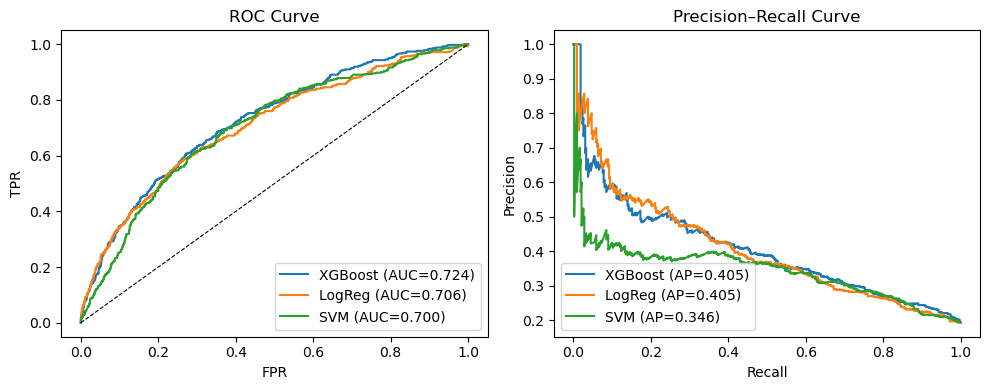

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

pxgb = xgb_tuned.predict_proba(X_test)[:, 1]  # XGBoost (Set-A)
y_true_xgb = y_test

plog = logreg.predict_proba(X_test_B_scaled)[:, 1]  # Logistic Regression (Set-B)
y_true_B = y_test_B  # set-B'nin y_test'i

psvm = svm.predict_proba(X_test_B_scaled)[:, 1]  # SVM (Set-B)


roc_xgb = roc_auc_score(y_true_xgb, pxgb)
pr_xgb  = average_precision_score(y_true_xgb, pxgb)

roc_log = roc_auc_score(y_true_B, plog)
pr_log  = average_precision_score(y_true_B, plog)

roc_svm = roc_auc_score(y_true_B, psvm)
pr_svm  = average_precision_score(y_true_B, psvm)


fpr_xgb, tpr_xgb, _ = roc_curve(y_true_xgb, pxgb)
fpr_log, tpr_log, _ = roc_curve(y_true_B,  plog)
fpr_svm, tpr_svm, _ = roc_curve(y_true_B,  psvm)

prec_xgb, rec_xgb, _ = precision_recall_curve(y_true_xgb, pxgb)
prec_log, rec_log, _ = precision_recall_curve(y_true_B,  plog)
prec_svm, rec_svm, _ = precision_recall_curve(y_true_B,  psvm)


fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_xgb:.3f})')   # ROC
ax[0].plot(fpr_log, tpr_log, label=f'LogReg (AUC={roc_log:.3f})')
ax[0].plot(fpr_svm, tpr_svm, label=f'SVM (AUC={roc_svm:.3f})')
ax[0].plot([0,1], [0,1], 'k--', lw=0.8)
ax[0].set_title('ROC Curve')
ax[0].set_xlabel('FPR')
ax[0].set_ylabel('TPR')
ax[0].legend(loc='lower right')

ax[1].plot(rec_xgb, prec_xgb, label=f'XGBoost (AP={pr_xgb:.3f})')  # PR
ax[1].plot(rec_log, prec_log, label=f'LogReg (AP={pr_log:.3f})')
ax[1].plot(rec_svm, prec_svm, label=f'SVM (AP={pr_svm:.3f})')
ax[1].set_title('Precision–Recall Curve')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend(loc='lower left')

plt.tight_layout()
plt.show()


In [ ]:
import joblib, json

joblib.dump(xgb_tuned, "xgb_final.pkl")

FEATURES = [
    'loc','v(g)','ev(g)','iv(g)','n','v','l','d','i','e','b','t',
    'lOCode','lOComment','lOBlank','locCodeAndComment',
    'uniq_Op','uniq_Opnd','total_Op','total_Opnd','branchCount'
]
BEST_THR = 0.529  

with open("bug_predict_config.json", "w") as f:
    json.dump({"features": FEATURES, "best_threshold": BEST_THR}, f, indent=2)

print("Kaydedildi: xgb_final.pkl ve bug_predict_config.json")


Kaydedildi: xgb_final.pkl ve bug_predict_config.json
